In [88]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imPipeline
from sklearn.feature_selection import f_classif, chi2
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [2]:
DATA_PATH = os.path.join(os.getcwd(), '..', 'dataset', 'Churn_Modelling.csv')
df = pd.read_csv(DATA_PATH)

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

In [4]:
df.drop(columns=['rownumber', 'customerid', 'surname'], inplace= True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   creditscore      10000 non-null  int64  
 1   geography        10000 non-null  object 
 2   gender           10000 non-null  object 
 3   age              10000 non-null  int64  
 4   tenure           10000 non-null  int64  
 5   balance          10000 non-null  float64
 6   numofproducts    10000 non-null  int64  
 7   hascrcard        10000 non-null  int64  
 8   isactivemember   10000 non-null  int64  
 9   estimatedsalary  10000 non-null  float64
 10  exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [6]:
df.describe()

,creditscore,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.isna().sum()

creditscore        0
geography          0
gender             0
age                0
tenure             0
balance            0
numofproducts      0
hascrcard          0
isactivemember     0
estimatedsalary    0
exited             0
dtype: int64

In [8]:
df['geography'].value_counts()

geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df['gender'].value_counts()

gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:
df['exited'].value_counts(normalize=True)

exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [11]:
df.dtypes

creditscore          int64
geography           object
gender              object
age                  int64
tenure               int64
balance            float64
numofproducts        int64
hascrcard            int64
isactivemember       int64
estimatedsalary    float64
exited               int64
dtype: object

In [12]:
df['tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

* `Data Visualizaation & Handling Outliers`
* `Univariate`

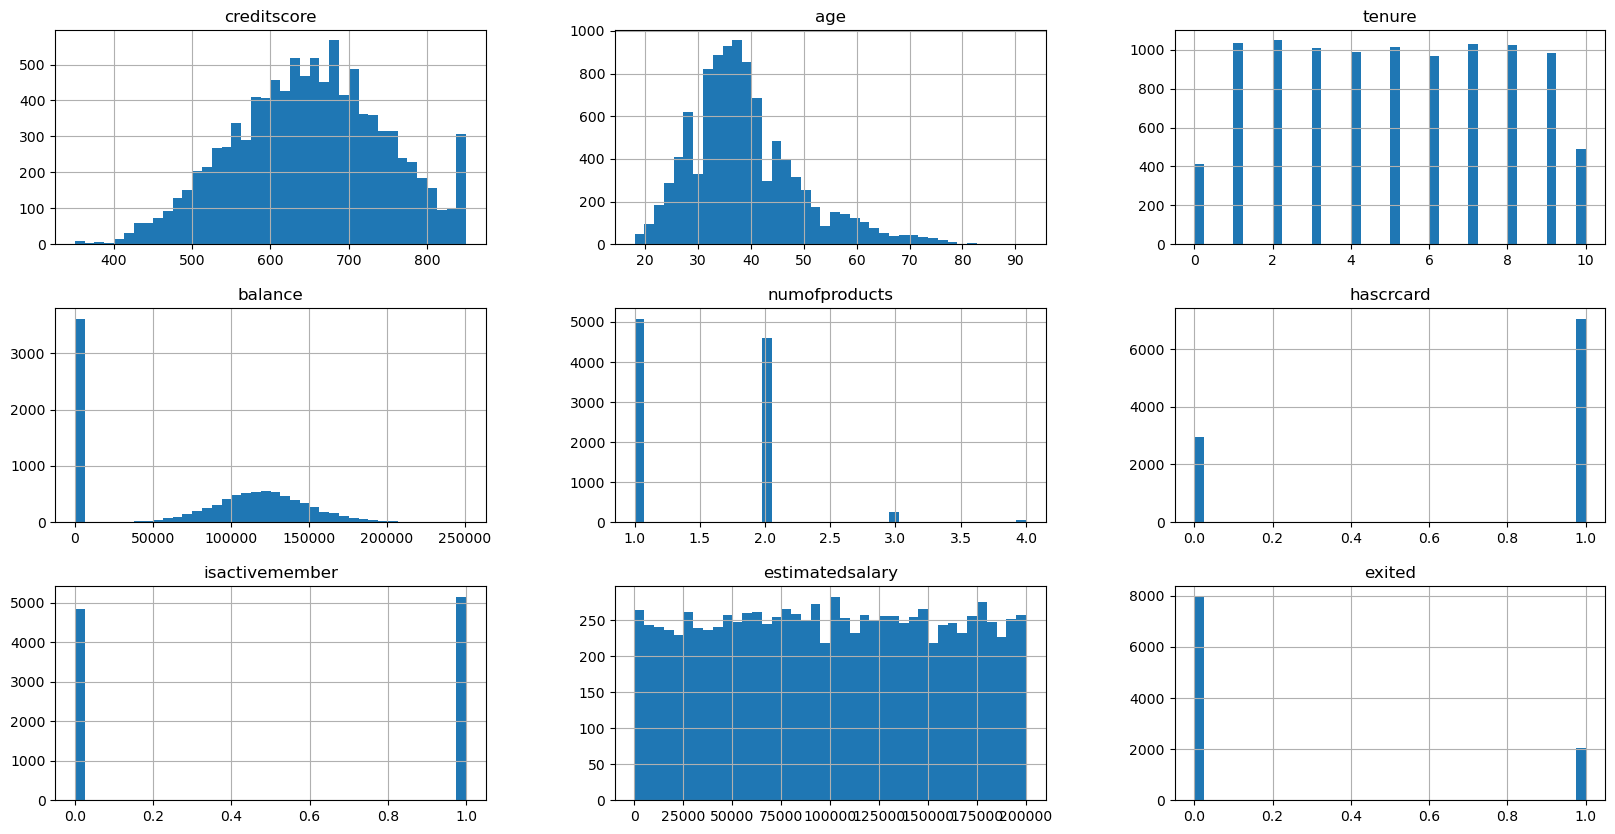

In [13]:
df.hist(figsize=(20, 10), bins=40)
plt.show()

`You can use powertransofrmer box cox or yea johnson which transofrm into normal dist`

In [14]:
for i in range(60, 81, 5):
    a = df[df['age'] > i]['exited'].value_counts()
    print(i, a)

60 exited
0    349
1    115
Name: count, dtype: int64
65 exited
0    229
1     35
Name: count, dtype: int64
70 exited
0    122
1     11
Name: count, dtype: int64
75 exited
0    44
1     1
Name: count, dtype: int64
80 exited
0    11
1     1
Name: count, dtype: int64


In [15]:
for i in range(60, 81, 5):
    a = df[df['age'] > i]['estimatedsalary'].mean()
    print(i, a)
df['estimatedsalary'].mean()

60 98126.17900862069
65 99943.6168939394
70 99570.12000000001
75 101700.84666666664
80 106388.09333333332


np.float64(100090.239881)

In [16]:
for i in range(60, 81, 5):
    a = df[df['age'] > i]['balance'].mean()
    print(i, a)
df['balance'].mean()

60 75742.59640086208
65 71321.85571969696
70 68197.01669172931
75 65442.341111111105
80 56090.92166666666


np.float64(76485.889288)

In [17]:
len(df)

10000

In [18]:
sub_df = df[df['age']>70]
len(sub_df)

133

In [19]:
df.drop(index=sub_df.index.tolist(), inplace=True)

In [20]:
len(df)

9867

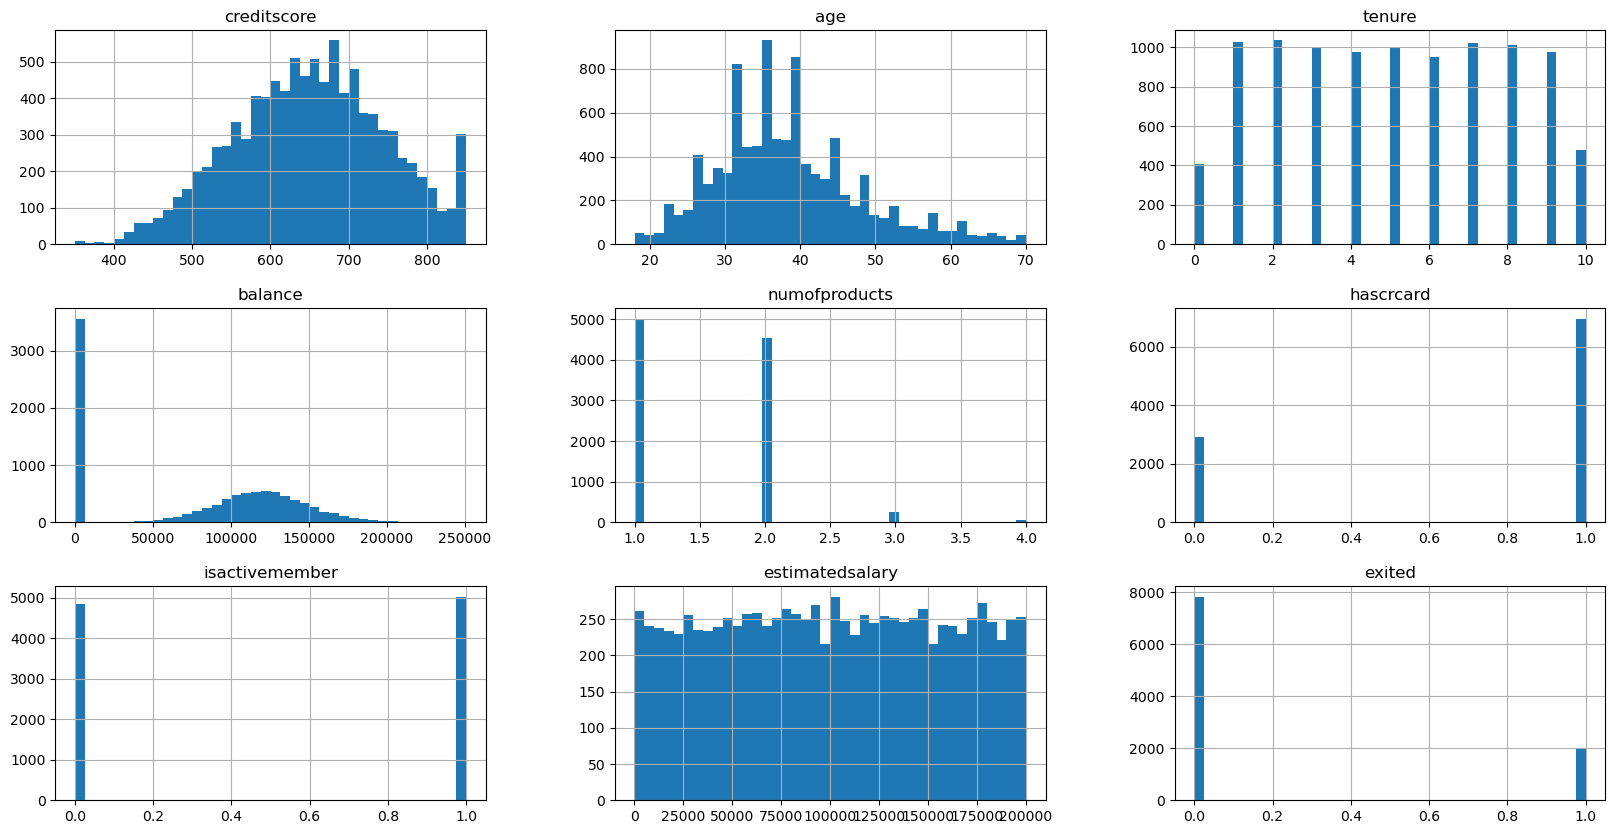

In [21]:
df.hist(figsize=(20, 10), bins=40)
plt.show()

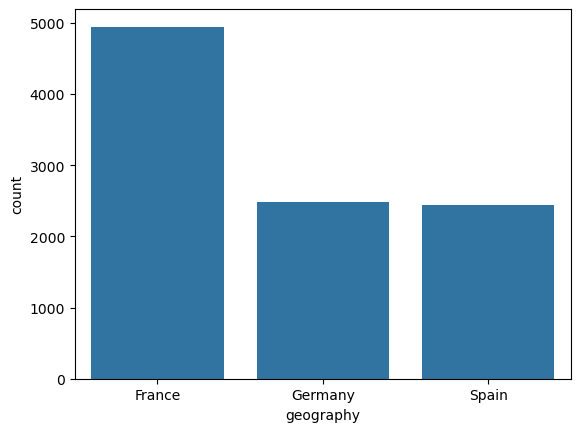

In [22]:
sns.countplot(data=df, x='geography', order=df['geography'].value_counts().index.tolist())
plt.show()

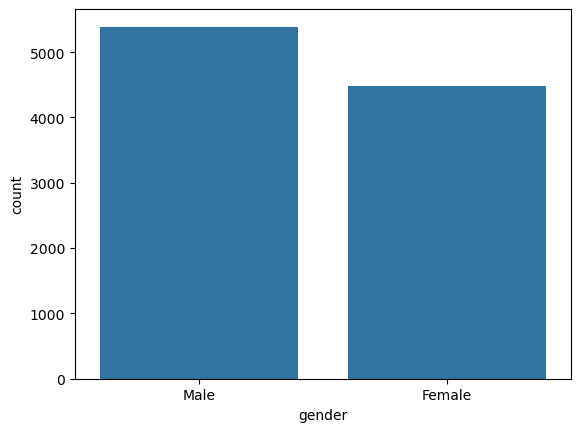

In [23]:
sns.countplot(data=df, x='gender', order=df['gender'].value_counts().index.tolist())
plt.show()

<Axes: ylabel='estimatedsalary'>

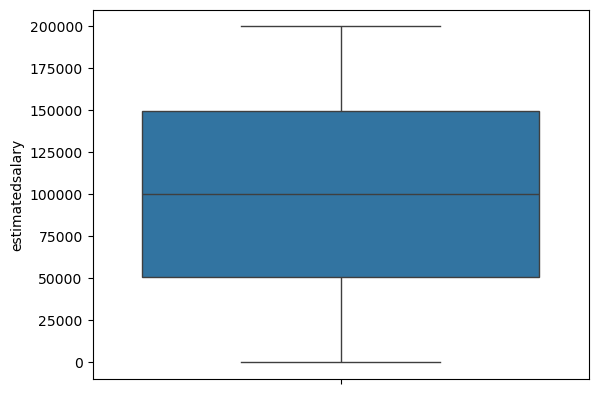

In [24]:
sns.boxplot(data=df, y='estimatedsalary')

`Bivariate`

<Axes: xlabel='gender', ylabel='estimatedsalary'>

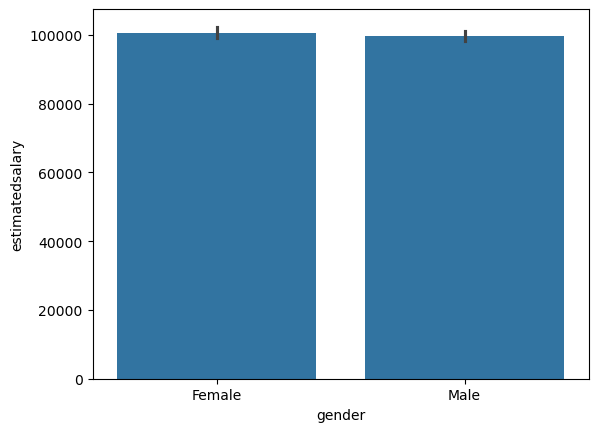

In [25]:
sns.barplot(data=df, x='gender', y='estimatedsalary')

<Axes: xlabel='tenure', ylabel='count'>

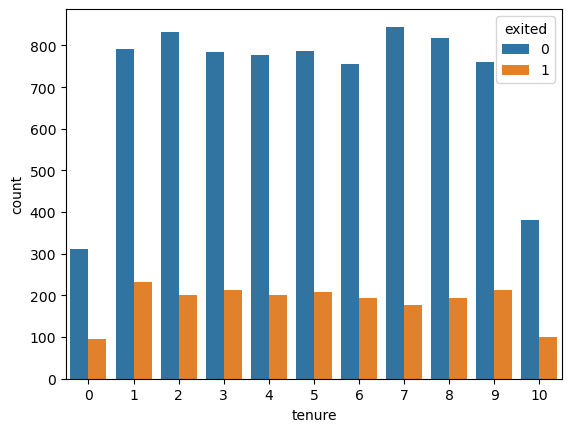

In [26]:
sns.countplot(data=df, x='tenure', hue='exited')

<Axes: xlabel='geography', ylabel='count'>

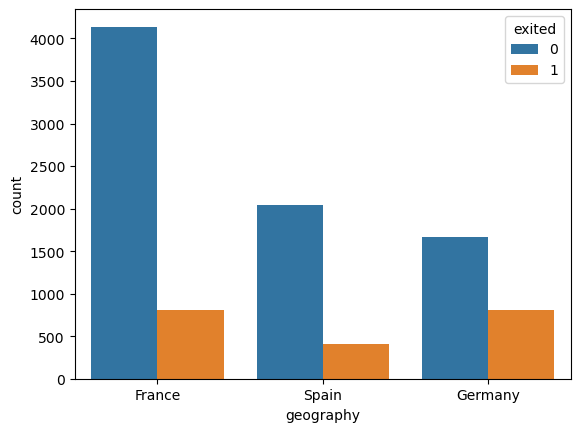

In [27]:
sns.countplot(data=df, x='geography', hue='exited')

`Split`

In [28]:
X = df.drop(columns='exited')
y = df['exited']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    random_state=42, test_size=0.2, stratify=y)

In [30]:
num_cols = ['creditscore', 'age', 'balance', 'estimatedsalary']
cat_cols = ['geography', 'gender']
ready_cols = list(set(X.columns.tolist()) - set(num_cols) - set(cat_cols))

In [31]:
#num X cat ANVOVA
_, p_val = f_classif(X=X_train[num_cols], y=y_train)
p_val

array([2.09019660e-002, 6.68515712e-203, 2.85917061e-022, 2.70551889e-001])

In [32]:
#CAT X CAR CHI2
_, p_val = chi2(X=OrdinalEncoder().fit_transform(X_train[cat_cols]), y=y_train)
p_val

array([3.49101904e-03, 4.98902164e-10])

In [33]:
#CAT X CAR CHI2
_, p_val = chi2(X=X_train[ready_cols], y=y_train)
p_val

array([5.53247706e-22, 4.10855241e-01, 4.24083169e-02, 6.97552861e-01])

In [34]:
df_temp = df[num_cols]
np.abs(df_temp.skew())
#mean for all bugt age

creditscore        0.070813
age                0.738466
balance            0.143785
estimatedsalary    0.000724
dtype: float64

In [35]:
#age will have a seperate pipeline since its the only one where we cant use mean
num_cols = list(set(num_cols) - set(['age']))
num_cols

['creditscore', 'estimatedsalary', 'balance']

In [36]:
num_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())]
)

age_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())]
)

categ_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(sparse_output=False, drop='first'))]
)

ready_pipeline = Pipeline(
    [('imputer', SimpleImputer(strategy='most_frequent'))]
)

preprocessor = ColumnTransformer(transformers=[
    ('numerical', num_pipeline, num_cols),
    ('categorical', categ_pipeline, cat_cols),
    ('ready', ready_pipeline, ready_cols),
    ('age', age_pipeline, ['age'])
])



In [37]:
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

* `Deal with imbalanced data`

In [38]:
vals_count = 1 - (np.bincount(y_train) / len(y_train))
vals_count = vals_count / sum(vals_count)

dict_weights = {}
for i in range(2):
    dict_weights[i] = vals_count[i]

dict_weights

{0: np.float64(0.2053718484733308), 1: np.float64(0.7946281515266692)}

In [41]:
y_train.value_counts(normalize=True)

exited
0    0.794628
1    0.205372
Name: proportion, dtype: float64

In [42]:
0.205372 /   0.794628

0.25845049507442475

In [43]:
over = SMOTE(k_neighbors=5, sampling_strategy=0.7, random_state=42)
X_train_final_resampled, y_trainfinal_resampled = over.fit_resample(X_train_final, y_train)

In [45]:
#Create folder for modedl path
MODELS_FOLDER_PATH = os.path.join(os.getcwd(), '..', 'models')
os.makedirs(MODELS_FOLDER_PATH, exist_ok=True)

In [46]:
#dump the preprocessor
joblib.dump(preprocessor, os.path.join(MODELS_FOLDER_PATH, 'preprocessor.pkl'))

['c:\\Users\\LEGION\\Desktop\\ML Projects\\Churn-Project\\notebooks\\..\\models\\preprocessor.pkl']

---

* `Building Model`
> `Consider eval metric to be f1-score`

In [ ]:
#1 based logistic regression
log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_final, y_train)

y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f'The f1_score using logistic regression model for training data is {score_train_log*100:.3f}')
print(f'The f1_score using logistic regression model for training data is {score_test_log*100:.3f}')

The f1_score using logistic regression model for training data is 36.324
The f1_score using logistic regression model for training data is 38.898


In [ ]:
#2 Logistic regression with class weights
log_clf = LogisticRegression(C=1.5, class_weight=dict_weights)
log_clf.fit(X_train_final, y_train)

y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f'The f1_score using logistic regression model for training data with class weights is {score_train_log*100:.3f}')
print(f'The f1_score using logistic regression model for training data with class weights is {score_test_log*100:.3f}')

The f1_score using logistic regression model for training data with class weights is 51.545
The f1_score using logistic regression model for training data with class weights is 50.401


In [76]:
#3 Logistic regression with SMOTE

log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_final_resampled, y_trainfinal_resampled)

y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f'The f1_score using logistic regression model for training data with SMOTE is {score_train_log*100:.3f}')
print(f'The f1_score using logistic regression model for training data with SMOTE is {score_test_log*100:.3f}')

The f1_score using logistic regression model for training data with SMOTE is 51.912
The f1_score using logistic regression model for training data with SMOTE is 51.087


In [58]:
vals_count = 1 - (np.bincount(y_trainfinal_resampled) / len(y_trainfinal_resampled))
vals_count = vals_count / sum(vals_count)

dict_weights_resampled = {}
for i in range(2):
    dict_weights[i] = vals_count[i]

dict_weights

{0: np.float64(0.4117426374038642), 1: np.float64(0.5882573625961358)}

In [ ]:
#4 Logistic regression with class weights and SMOTE
log_clf = LogisticRegression(C=1.5, class_weight=dict_weights_resampled)
log_clf.fit(X_train_final_resampled, y_trainfinal_resampled)

y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f'The f1_score using logistic regression model for training data with SMOTE and class weight is {score_train_log*100:.3f}')
print(f'The f1_score using logistic regression model for training data with SMOTE and class weight is {score_test_log*100:.3f}')


The f1_score using logistic regression model for training data with SMOTE and class weight is 51.912
The f1_score using logistic regression model for training data with SMOTE and class weight is 51.087


<Axes: >

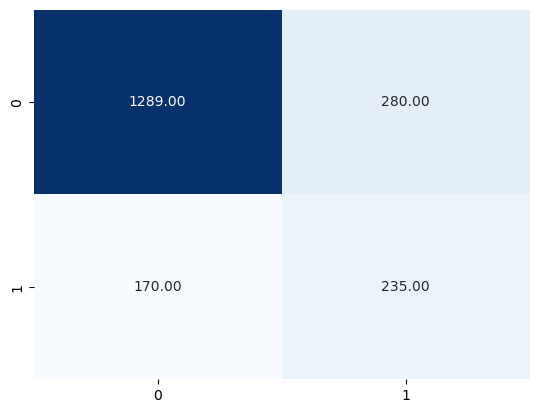

In [68]:
sns.heatmap(
    confusion_matrix(y_true=y_test, y_pred=y_pred_test_log),
    cmap='Blues', annot=True, fmt='.2f', cbar=False)

In [69]:
print(classification_report(y_test, y_pred_test_log))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1569
           1       0.46      0.58      0.51       405

    accuracy                           0.77      1974
   macro avg       0.67      0.70      0.68      1974
weighted avg       0.80      0.77      0.78      1974



* `Random Forest`

In [77]:
#4 Logistic regression with class weights and SMOTE
rf_clf = RandomForestClassifier(n_estimators=150, max_depth=5 , random_state=42, class_weight=dict_weights_resampled)
rf_clf.fit(X_train_final_resampled, y_trainfinal_resampled)

y_pred_train_log = rf_clf.predict(X_train_final)
y_pred_test_log = rf_clf.predict(X_test_final)

score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f'The f1_score using logistic regression model for training data with SMOTE and class weight is {score_train_log*100:.3f}')
print(f'The f1_score using logistic regression model for training data with SMOTE and class weight is {score_test_log*100:.3f}')


The f1_score using logistic regression model for training data with SMOTE and class weight is 62.037
The f1_score using logistic regression model for training data with SMOTE and class weight is 60.598


* `RF tuning`

In [83]:
rf_base_clf = RandomForestClassifier(n_estimators=150, max_depth=5 , random_state=42, class_weight=dict_weights_resampled)

params_set = {
    'n_estimators': np.arange(50, 400, 50),
    'max_depth': np.arange(2, 10, 2) 
}

grid_search_rf = GridSearchCV(estimator=rf_base_clf, 
                            param_grid=params_set, cv=5, n_jobs=-1, verbose=4, scoring='f1')

grid_search_rf.fit(X_train_final, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': array([2, 4, 6, 8]), 'n_estimators': array([ 50, 1...50, 300, 350])}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,np.int64(100)


In [84]:
grid_search_rf.best_score_, grid_search_rf.best_params_

(np.float64(0.5491750368154837),
 {'max_depth': np.int64(8), 'n_estimators': np.int64(100)})

In [85]:
#4 Logistic regression with class weights and SMOTE
rf_tuned = grid_search_rf.best_estimator_

y_pred_train_log = rf_tuned.predict(X_train_final)
y_pred_test_log = rf_tuned.predict(X_test_final)

score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f'The f1_score using logistic regression model for training data with SMOTE and class weight is {score_train_log*100:.3f}')
print(f'The f1_score using logistic regression model for training data with SMOTE and class weight is {score_test_log*100:.3f}')


The f1_score using logistic regression model for training data with SMOTE and class weight is 62.781
The f1_score using logistic regression model for training data with SMOTE and class weight is 57.862


In [89]:
#RF tuning with resampling

rf_base_clf = RandomForestClassifier(n_estimators=150, max_depth=5 , random_state=42, class_weight=dict_weights_resampled)

pipeline = imPipeline([
    ('smote', SMOTE(random_state=42)),               # Step 1: Resampling happens ONLY inside each fold
    ('rf', RandomForestClassifier(random_state=42))  # Step 2: Fit the model
])

params_set = {
    'rf__n_estimators': np.arange(50, 400, 50),
    'rf__max_depth': np.arange(2, 10, 2) 
}

grid_search_rf = GridSearchCV(
    estimator=pipeline,
    param_grid=params_set,
    cv=5,
    n_jobs=-1,
    verbose=4,
    scoring='f1'
)

grid_search_rf.fit(X_train_final, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'rf__max_depth': array([2, 4, 6, 8]), 'rf__n_estimators': array([ 50, 1...50, 300, 350])}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,sampling_strategy,'auto'
